# 03. Train DDPG Bandwidth Allocator

In this notebook, we implement and train a DDPG agent to dynamically allocate bandwidth across patients under joint contention. The actor network outputs raw logits, which are then normalized using the **Softmax** activation to form a probability distribution over the active patients. This distribution is scaled by the total available bandwidth pool constraint.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import config
from environment import NetworkSlicingEnv
import time

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

C:\Users\saran\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Using device: cpu


## 1. Define DDPG Network Architectures

In [2]:
class Actor(nn.Module):
    def __init__(self, state_dim=10, action_dim=1):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, action_dim)
        
    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        # Direct bounded bandwidth output scaled by BW_MAX = 15.0
        return torch.sigmoid(self.fc3(x)) * 15.0

class Critic(nn.Module):
    def __init__(self, state_dim=10, action_dim=1):
        super(Critic, self).__init__()
        # Input size: local state (10) + local action (1) + contention pressure (1) + slice one-hot (5) = 17
        self.fc1 = nn.Linear(state_dim + action_dim + 1 + 5, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        
    def forward(self, state, action, contention_pressure, slice_onehot):
        if contention_pressure.dim() == 1:
            contention_pressure = contention_pressure.unsqueeze(-1)
        if contention_pressure.size(0) != state.size(0):
            contention_pressure = contention_pressure.expand(state.size(0), -1)
        x = torch.cat([state, action, contention_pressure, slice_onehot], dim=-1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def soft_update(target, source, tau):
    for target_param, param in zip(target.parameters(), source.parameters()):
        target_param.data.copy_(target_param.data * (1.0 - tau) + param.data * tau)


## 2. Replay Buffer (Step-based Time Series Storage)

In [3]:
class StepReplayBuffer:
    def __init__(self, capacity=5000000, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.states = np.zeros((capacity, 10), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, 10), dtype=np.float32)
        self.contentions = np.zeros(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.slice_ids = np.zeros(capacity, dtype=np.int32)
        self.slice_onehot = np.zeros((capacity, 5), dtype=np.float32)
        self.position = 0
        self.size = 0
        
    def store(self, states, actions, rewards, next_states, contention, slice_ids=None):
        num_patients = len(states)
        max_p = np.max(self.priorities[:self.size]) if self.size > 0 else 1.0
        
        idx = (self.position + np.arange(num_patients)) % self.capacity
        
        self.states[idx] = states
        self.actions[idx] = actions
        self.rewards[idx] = rewards
        self.next_states[idx] = next_states
        self.contentions[idx] = contention
        self.priorities[idx] = max_p
        if slice_ids is not None:
            self.slice_ids[idx] = slice_ids
            self.slice_onehot[idx] = np.eye(5)[slice_ids - 1]
        
        self.position = (self.position + num_patients) % self.capacity
        self.size = min(self.size + num_patients, self.capacity)
        
    def sample(self, batch_size, beta=0.4):
        N = self.size
        prios = self.priorities[:N]
        # Bound priorities to prevent numerical instability or overflow
        prios = np.clip(prios, 1e-6, 10.0)
        probs = prios ** self.alpha
        probs_sum = np.sum(probs)
        if probs_sum > 0:
            probs /= probs_sum
        else:
            probs = np.ones(N) / N
        
        indices = np.random.choice(N, batch_size, replace=False, p=probs)
        
        # Fast pre-allocated array slicing directly to PyTorch tensors
        S = torch.from_numpy(self.states[indices])
        A = torch.from_numpy(self.actions[indices])
        R = torch.from_numpy(self.rewards[indices])
        S_next = torch.from_numpy(self.next_states[indices])
        C = torch.from_numpy(self.contentions[indices]).unsqueeze(-1)
        SL = torch.from_numpy(self.slice_onehot[indices])
        
        weights = (N * probs[indices]) ** (-beta)
        weights /= np.max(weights)
        
        return (S, A, R, S_next, C, SL), indices, torch.tensor(weights, dtype=torch.float32)
        
    def update_priorities(self, indices, errors, epsilon=1e-6):
        # Vectorized array assignment
        clipped_errors = np.clip(np.abs(errors), 0.0, 10.0)
        self.priorities[indices] = clipped_errors + epsilon

    def __len__(self):
        return self.size


## 3. Setup Environment and Training Config

In [4]:
df = pd.read_csv('dataset.csv')
env = NetworkSlicingEnv(df)
patient_to_slice = df.drop_duplicates('PatientID').set_index('PatientID')['SliceID'].to_dict()

# Setup training parameters
all_train_patient_ids = list(range(1, config.TRAIN_PATIENT_LIMIT + 1)) # Patients 1-8000

# Initialize DDPG Networks (state_dim=10)
actor = Actor(state_dim=10, action_dim=1).to(device)
actor_target = Actor(state_dim=10, action_dim=1).to(device)
actor_target.load_state_dict(actor.state_dict())

critic = Critic(state_dim=10, action_dim=1).to(device)
critic_target = Critic(state_dim=10, action_dim=1).to(device)
critic_target.load_state_dict(critic.state_dict())

# Optimizers with calibrated learning rates
optimizer_actor = optim.Adam(actor.parameters(), lr=1e-4)
optimizer_critic = optim.Adam(critic.parameters(), lr=1e-4)

# Replay Buffer (Capacity changed to 5,000,000 patient transitions)
replay_buffer = StepReplayBuffer(capacity=5000000)

# Hyperparameters
gamma = 0.99
tau = 0.005
batch_size = 16000  # Flat batch size of 16000 patient transitions
episodes = 100  
max_steps = 79
noise_std = 0.2
noise_decay = 0.995
update_every = 2  
num_patients_batch = 1000 


## 4. DDPG Multi-Patient Contention Training Loop

In [5]:
episode_rewards = []
actor_losses = []
critic_losses = []
actor_grad_norms = []
best_mean_reward = -float('inf')

start_time = time.time()
print("Starting DDPG joint training...")

for ep in range(episodes):
    ep_patient_ids = np.random.choice(all_train_patient_ids, num_patients_batch, replace=False)
    ep_slice_ids = np.array([patient_to_slice[p] for p in ep_patient_ids], dtype=np.int32)
    # Ordering assertion: env uses ep_patient_ids as the Categorical order for ALL timesteps
    assert len(ep_slice_ids) == num_patients_batch, (
        f"slice_ids length {len(ep_slice_ids)} != cohort {num_patients_batch}"
    )
    TOTAL_BW_train = config.TOTAL_BW * (num_patients_batch / 10000.0) # 3000.0
    
    state = env.reset(ep_patient_ids, start_time=0)
    ep_rew = 0.0
    ep_actor_loss = []
    ep_critic_loss = []
    ep_grad_norms = []
    
    # Calculate beta with linear annealing from 0.4 to 1.0 across episodes
    beta = 0.4 + (1.0 - 0.4) * (ep / (episodes - 1)) if episodes > 1 else 0.4
    
    for t in range(max_steps):
        # 1. Choose actions with noise
        state_t = torch.tensor(state, dtype=torch.float32).to(device)
        actor.eval()
        with torch.no_grad():
            raw_actions = actor(state_t).cpu().numpy() # Shape: (1000, 1), range [0, 15]
            
        # Compute C_t for the raw action output
        C_t = np.sum(raw_actions) / TOTAL_BW_train
        
        # Add exploration noise to raw actions (scaled relative to max action 15.0)
        noise = np.random.normal(0, noise_std * 15.0, size=raw_actions.shape)
        noisy_actions = np.clip(raw_actions + noise, 0.05, 15.0)
        
        # Scale actions to satisfy the total bandwidth constraint
        sum_noisy = np.sum(noisy_actions)
        actions = noisy_actions * (TOTAL_BW_train / sum_noisy) # Shape: (1000, 1)
        
        # 2. Step environment
        next_state, reward, done, info = env.step(actions)
        ep_rew += reward.mean() # log mean patient reward
        
        # 3. Store transition (scaled reward by 0.01 for gradient stability, with C_t)
        reward_t = reward.reshape(-1, 1) * 0.01
        step_slice_ids = env.time_data[env.current_time - 1]['SliceID']
        replay_buffer.store(state, noisy_actions, reward_t, next_state, C_t, step_slice_ids)
        
        # 4. Train Networks
        if len(replay_buffer) >= batch_size and t % update_every == 0:
            actor.train()
            critic.train()
            
            # Sample batch of individual patient transitions using PER
            (S, A, R, S_next, C, SL), indices, weights = replay_buffer.sample(batch_size, beta=beta)
            
            S = S.to(device)
            A = A.to(device)
            R = R.to(device)
            S_next = S_next.to(device)
            C = C.to(device)
            SL = SL.to(device)
            weights = weights.to(device)
            
            # --- Critic loss ---
            current_Q = critic(S, A, C, SL)
            
            with torch.no_grad():
                next_actions = actor_target(S_next)
                next_Q = critic_target(S_next, next_actions, C, SL)
                target_Q = R + gamma * next_Q
            
            # Compute TD errors: delta_i = target_Q - current_Q
            td_errors = (target_Q - current_Q).detach().cpu().numpy().flatten()
            
            # Apply importance sampling weight to critic loss
            loss_critic = (weights * nn.functional.mse_loss(current_Q, target_Q, reduction='none').flatten()).mean()
            
            # --- Actor loss ---
            pred_raw = actor(S)
            sum_pred = torch.sum(pred_raw, dim=0, keepdim=True)
            reference_bw = batch_size * (TOTAL_BW_train / num_patients_batch)
            # Scaling with NO detach on sum_pred to allow gradient-sharing feedback
            pred_actions = pred_raw * (reference_bw / sum_pred)
            loss_actor = -critic(S, pred_actions, C, SL).mean()

            # Update Actor first
            optimizer_actor.zero_grad()
            loss_actor.backward()
            
            # Compute Actor L2 gradient norm
            total_norm = 0.0
            for p in actor.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            ep_grad_norms.append(total_norm)
            
            # Clip gradients to prevent explosion
            torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=1.0)
            optimizer_actor.step()
            ep_actor_loss.append(loss_actor.item())
            
            # Update Critic
            optimizer_critic.zero_grad()
            loss_critic.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=1.0)
            optimizer_critic.step()
            ep_critic_loss.append(loss_critic.item())
            
            # Update replay priorities using latest TD errors
            replay_buffer.update_priorities(indices, td_errors)
            
            # Soft update target networks
            soft_update(actor_target, actor, tau)
            soft_update(critic_target, critic, tau)
            
        state = next_state
        if done:
            break
            
    # Decay exploration noise once per episode
    noise_std = max(noise_std * noise_decay, 0.05)
    
    episode_rewards.append(ep_rew)
    actor_losses.append(np.mean(ep_actor_loss) if ep_actor_loss else 0)
    critic_losses.append(np.mean(ep_critic_loss) if ep_critic_loss else 0)
    actor_grad_norms.append(np.mean(ep_grad_norms) if ep_grad_norms else 0.0)
    
    # Save best checkpoint
    if ep_rew > best_mean_reward:
        best_mean_reward = ep_rew
        torch.save(actor.state_dict(), 'ddpg_actor_latest_best.pth')
        torch.save(critic.state_dict(), 'ddpg_critic_latest_best.pth')
        print(f"New best mean reward: {best_mean_reward:.2f}. Checkpoint saved.")
    
    if (ep + 1) % 25 == 0 or ep == 0 or ep == episodes - 1:
        print(f"Episode {ep+1}/{episodes} - Mean Reward: {ep_rew:.2f} - Actor Loss: {actor_losses[-1]:.4f} - Critic Loss: {critic_losses[-1]:.4f} - Grad Norm: {actor_grad_norms[-1]:.4f} - Noise Std: {noise_std:.4f}")
        # --- Per-slice priority stats at print cadence ---
        _N = replay_buffer.size
        _prios = replay_buffer.priorities[:_N]
        _sids  = replay_buffer.slice_ids[:_N]
        _snames = {1: "S1(Emrg)", 2: "S2(ICU)", 3: "S3(ECG)", 4: "S4(Tele)", 5: "S5(Vid)"}
        _parts = []
        for _s in range(1, 6):
            _mask = _sids == _s
            if _mask.sum() == 0:
                continue
            _p = _prios[_mask]
            _parts.append(
                f"{_snames[_s]} mean={_p.mean():.4f} std={_p.std():.4f} "
                f"min={_p.min():.5f} max={_p.max():.4f} n={_mask.sum()}"
            )
        print("[Ep " + str(ep + 1) + "] Priority stats | " + " | ".join(_parts))


# Save final priority and slice_id arrays for offline inspection
np.save("replay_priorities_final.npy", replay_buffer.priorities[:replay_buffer.size].copy())
np.save("replay_slice_ids_final.npy",  replay_buffer.slice_ids[:replay_buffer.size].copy())
print("Saved final priority array (" + str(replay_buffer.size) + " entries) to disk.")

# Final per-slice priority summary
_N = replay_buffer.size
_prios = replay_buffer.priorities[:_N]
_sids  = replay_buffer.slice_ids[:_N]
_snames = {1: "S1(Emrg)", 2: "S2(ICU)", 3: "S3(ECG)", 4: "S4(Tele)", 5: "S5(Vid)"}
print("\n=== FINAL PRIORITY STATS BY SLICE ===")
print("Overall: n=" + str(_N) + " min=" + str(round(_prios.min(), 5)) + " max=" + str(round(_prios.max(), 4)) + " mean=" + str(round(_prios.mean(), 4)) + " std=" + str(round(_prios.std(), 4)))
for _s in range(1, 6):
    _mask = _sids == _s
    if _mask.sum() == 0:
        continue
    _p = _prios[_mask]
    print(_snames[_s] + ": n=" + str(_mask.sum()) + " min=" + str(round(_p.min(), 5)) + " max=" + str(round(_p.max(), 4)) + " mean=" + str(round(_p.mean(), 4)) + " std=" + str(round(_p.std(), 4)))

# Report gradient norm stats for first 50 and last 50 episodes
first_50 = actor_grad_norms[:50]
last_50 = actor_grad_norms[-50:]
print(f"First 50 episodes actor gradient norm - Mean: {np.mean(first_50):.4f}, Range: [{np.min(first_50):.4f}, {np.max(first_50):.4f}]")
print(f"Last 50 episodes actor gradient norm - Mean: {np.mean(last_50):.4f}, Range: [{np.min(last_50):.4f}, {np.max(last_50):.4f}]")


Starting DDPG joint training...


New best mean reward: -9864.84. Checkpoint saved.
Episode 1/100 - Mean Reward: -9864.84 - Actor Loss: 0.0463 - Critic Loss: 1.5362 - Grad Norm: 0.0008 - Noise Std: 0.1990
[Ep 1] Priority stats | S1(Emrg) mean=4.1181 std=1.5476 min=0.00008 max=5.0000 n=16046 | S2(ICU) mean=2.0313 std=2.0477 min=0.00001 max=5.0000 n=15772 | S3(ECG) mean=0.2956 std=0.7391 min=0.00000 max=5.0000 n=15641 | S4(Tele) mean=0.2835 std=0.7547 min=0.00000 max=5.0000 n=15636 | S5(Vid) mean=0.2589 std=0.7261 min=0.00002 max=5.0000 n=15905


New best mean reward: -9852.16. Checkpoint saved.


Episode 25/100 - Mean Reward: -10294.49 - Actor Loss: 6.5955 - Critic Loss: 0.3093 - Grad Norm: 0.0908 - Noise Std: 0.1764
[Ep 25] Priority stats | S1(Emrg) mean=1.7918 std=1.1783 min=0.00000 max=5.0000 n=397549 | S2(ICU) mean=1.7458 std=1.1860 min=0.00001 max=5.0000 n=394648 | S3(ECG) mean=0.9184 std=1.0404 min=0.00000 max=5.0000 n=393327 | S4(Tele) mean=0.8483 std=1.0551 min=0.00000 max=5.0000 n=393405 | S5(Vid) mean=0.8447 std=1.0519 min=0.00000 max=5.0000 n=396071


New best mean reward: -9774.28. Checkpoint saved.


...

New best mean reward: -8477.46. Checkpoint saved.


New best mean reward: -8416.61. Checkpoint saved.


New best mean reward: -8324.77. Checkpoint saved.


Episode 100/100 - Mean Reward: -8510.16 - Actor Loss: 21.8138 - Critic Loss: 0.0632 - Grad Norm: 0.0553 - Noise Std: 0.1212
[Ep 100] Priority stats | S1(Emrg) mean=1.5785 std=1.4097 min=0.00000 max=5.0000 n=1007139 | S2(ICU) mean=1.8053 std=1.4076 min=0.00000 max=5.0000 n=999621 | S3(ECG) mean=1.2550 std=1.1775 min=0.00000 max=5.0000 n=994087 | S4(Tele) mean=1.1174 std=1.1125 min=0.00000 max=5.0000 n=998041 | S5(Vid) mean=1.1931 std=1.0992 min=0.00000 max=5.0000 n=1001112
Saved final priority array (5000000 entries) to disk.

=== FINAL PRIORITY STATS BY SLICE ===


Overall: n=5000000 min=0.0 max=5.0 mean=1.3903 std=1.2763
S1(Emrg): n=1007139 min=0.0 max=5.0 mean=1.5785 std=1.4097
S2(ICU): n=999621 min=0.0 max=5.0 mean=1.8053 std=1.4076
S3(ECG): n=994087 min=0.0 max=5.0 mean=1.255 std=1.1775
S4(Tele): n=998041 min=0.0 max=5.0 mean=1.1174 std=1.1125
S5(Vid): n=1001112 min=0.0 max=5.0 mean=1.1931 std=1.0992
First 50 episodes actor gradient norm - Mean: 0.0540, Range: [0.0008, 0.1652]
Last 50 episodes actor gradient norm - Mean: 0.0336, Range: [0.0244, 0.0553]


## 5. Plot Training Convergence Curves

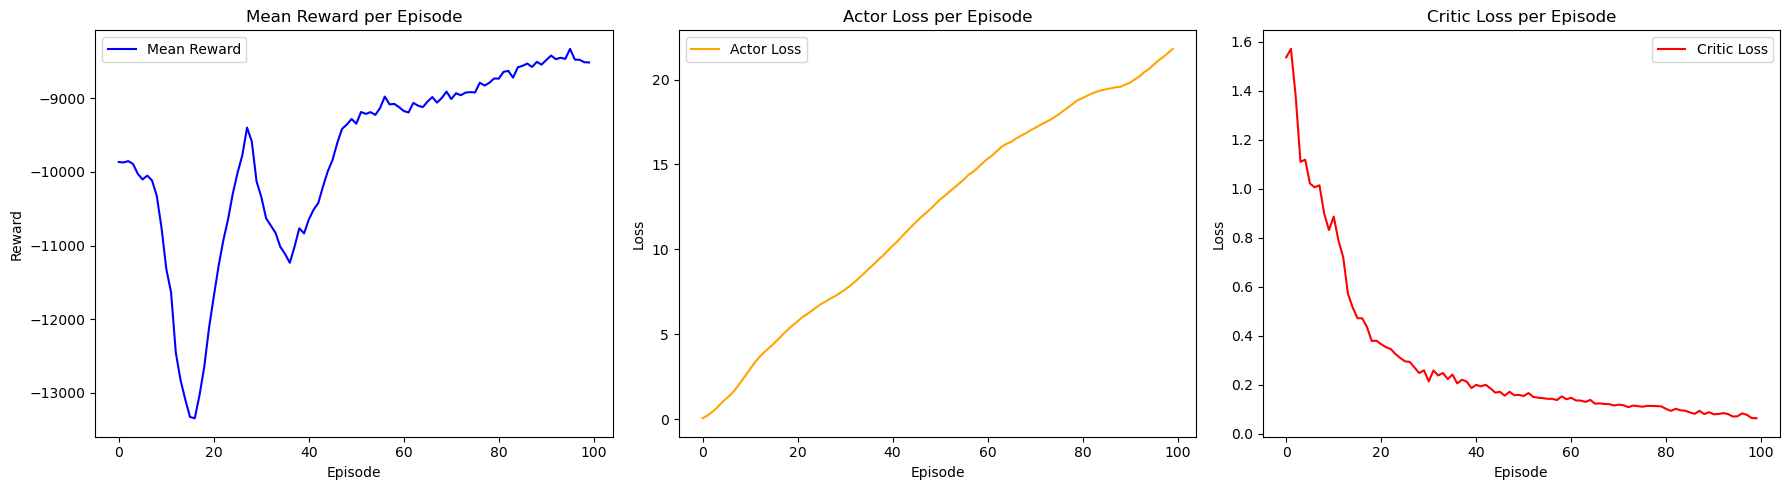

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(episode_rewards, color='blue', label='Mean Reward')
axes[0].set_title("Mean Reward per Episode")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].legend()

axes[1].plot(actor_losses, color='orange', label='Actor Loss')
axes[1].set_title("Actor Loss per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(critic_losses, color='red', label='Critic Loss')
axes[2].set_title("Critic Loss per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Save Trained Model Weights

In [7]:
torch.save(actor.state_dict(), 'ddpg_actor_latest.pth')
torch.save(critic.state_dict(), 'ddpg_critic_latest.pth')
print("DDPG actor and critic weights saved successfully!")

DDPG actor and critic weights saved successfully!
